# 04 — Confidence Monitoring & Hallucination Detection
> Measure whether the model's confidence scores actually match its accuracy. Compute ECE, detect confidence gaps, apply Temperature Scaling recalibration.

In [2]:
# Load model and compute predictions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize_scalar

df = pd.read_csv("creditcard.csv")
df_sorted = df.sort_values('Time').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

X_test  = df_sorted.iloc[split_idx:].drop("Class", axis=1)
y_test  = df_sorted.iloc[split_idx:]["Class"].values

scaler = joblib.load("models/scaler.pkl")
model  = joblib.load("models/best_model.pkl")

X_test_scaled = scaler.transform(X_test)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred  = model.predict(X_test_scaled)

print(f"Test samples: {len(y_test)}")
print(f"Fraud count:  {y_test.sum()}")
print(f"Model AUC:    {roc_auc_score(y_test, y_proba):.4f}")


Test samples: 56962
Fraud count:  75
Model AUC:    0.9445


In [3]:
# Compute Expected Calibration Error (ECE)
# ================================================================
# EXPECTED CALIBRATION ERROR (ECE)
# ================================================================
def compute_ece(y_true, y_proba, n_bins=10):
    """
    ECE: How much does confidence deviate from actual accuracy?
    Perfect calibration = ECE of 0.
    """
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_stats = []
    
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_proba >= lo) & (y_proba < hi)
        if mask.sum() == 0:
            continue
        n_in_bin   = mask.sum()
        avg_conf   = y_proba[mask].mean()
        avg_acc    = (y_true[mask] == 1).mean()  # actual fraud rate in bin
        gap        = abs(avg_conf - avg_acc)
        ece       += (n_in_bin / len(y_true)) * gap
        bin_stats.append({
            'bin_lo': round(lo, 2), 'bin_hi': round(hi, 2),
            'count': int(n_in_bin),
            'avg_confidence': round(float(avg_conf), 4),
            'avg_accuracy':   round(float(avg_acc), 4),
            'gap': round(float(gap), 4)
        })
    
    return float(ece), bin_stats

ece_before, bin_stats = compute_ece(y_test, y_proba)
print(f"Expected Calibration Error (ECE): {ece_before:.4f}")
print("\nBin-level breakdown:")
for b in bin_stats:
    flag = " ← HIGH GAP" if b['gap'] > 0.1 else ""
    print(f"  [{b['bin_lo']:.1f}-{b['bin_hi']:.1f}]  n={b['count']:5d}  "
          f"conf={b['avg_confidence']:.3f}  acc={b['avg_accuracy']:.3f}  "
          f"gap={b['gap']:.3f}{flag}")


Expected Calibration Error (ECE): 0.0003

Bin-level breakdown:
  [0.0-0.1]  n=56887  conf=0.000  acc=0.000  gap=0.000
  [0.1-0.2]  n=   14  conf=0.127  acc=0.214  gap=0.087
  [0.2-0.3]  n=    4  conf=0.290  acc=0.250  gap=0.040
  [0.3-0.4]  n=    4  conf=0.360  acc=1.000  gap=0.640 ← HIGH GAP
  [0.4-0.5]  n=    2  conf=0.470  acc=1.000  gap=0.530 ← HIGH GAP
  [0.5-0.6]  n=    6  conf=0.542  acc=1.000  gap=0.458 ← HIGH GAP
  [0.6-0.7]  n=    8  conf=0.660  acc=0.875  gap=0.215 ← HIGH GAP
  [0.7-0.8]  n=    6  conf=0.752  acc=1.000  gap=0.248 ← HIGH GAP
  [0.8-0.9]  n=   24  conf=0.853  acc=1.000  gap=0.147 ← HIGH GAP
  [0.9-1.0]  n=    7  conf=0.933  acc=1.000  gap=0.067


In [4]:
# Confidence gap analysis — baseline vs drifted
# ================================================================
# CONFIDENCE GAP OVER DRIFTED DATA
# ================================================================
X_drift_s3 = np.load("outputs/X_drift_s3.npy")
y_drift_s3 = np.load("outputs/y_drift_s3.npy")

proba_drift = model.predict_proba(X_drift_s3)[:, 1]
pred_drift  = model.predict(X_drift_s3)

mean_confidence_drift = np.mean(np.max(model.predict_proba(X_drift_s3), axis=1))
accuracy_drift        = accuracy_score(y_drift_s3, pred_drift)
confidence_gap_drift  = mean_confidence_drift - accuracy_drift

ece_drift, _ = compute_ece(y_drift_s3, proba_drift)

print("Confidence Analysis: Baseline vs Drifted")
print(f"{'Metric':<30} {'Baseline':>12} {'Drifted':>12}")
print(" " * 56)
print(f"{'Mean Confidence':<30} {np.mean(np.max(model.predict_proba(X_test_scaled), axis=1)):>12.4f} {mean_confidence_drift:>12.4f}")
print(f"{'Accuracy':<30} {accuracy_score(y_test, y_pred):>12.4f} {accuracy_drift:>12.4f}")
print(f"{'Confidence Gap':<30} {np.mean(np.max(model.predict_proba(X_test_scaled), axis=1)) - accuracy_score(y_test, y_pred):>12.4f} {confidence_gap_drift:>12.4f}")
print(f"{'ECE':<30} {ece_before:>12.4f} {ece_drift:>12.4f}")
print("\nNote: Large confidence gap on drifted data = model overconfident = hallucination-like behavior")


Confidence Analysis: Baseline vs Drifted
Metric                             Baseline      Drifted
                                                        
Mean Confidence                      0.9994       0.9798
Accuracy                             0.9995       0.9988
Confidence Gap                      -0.0001      -0.0190
ECE                                  0.0003       0.0194

Note: Large confidence gap on drifted data = model overconfident = hallucination-like behavior


In [5]:
# Temperature Scaling — recalibration
# ================================================================
# TEMPERATURE SCALING — Calibration Fix
# ================================================================
def temperature_scale(logits, T):
    """Divide logits by temperature T to soften probabilities"""
    return 1 / (1 + np.exp(-logits / T))

# Get raw logits from LR decision function
# For RF we use log-odds transformation
eps = 1e-9
logits_before = np.log(y_proba + eps) - np.log(1 - y_proba + eps)

def ece_loss(T):
    proba_scaled = temperature_scale(logits_before, T)
    ece, _ = compute_ece(y_test, proba_scaled)
    return ece

result = minimize_scalar(ece_loss, bounds=(0.1, 10.0), method='bounded')
optimal_T = result.x

proba_calibrated = temperature_scale(logits_before, optimal_T)
ece_after, bin_stats_after = compute_ece(y_test, proba_calibrated)

print(f"Optimal Temperature: T = {optimal_T:.5f}")
print(f"ECE Before calibration: {ece_before:.5f}")
print(f"ECE After  calibration: {ece_after:.5f}")
print(f"ECE improvement: {((ece_before - ece_after)/ece_before)*100:.1f}%")


Optimal Temperature: T = 0.99059
ECE Before calibration: 0.00028
ECE After  calibration: 0.00025
ECE improvement: 11.7%


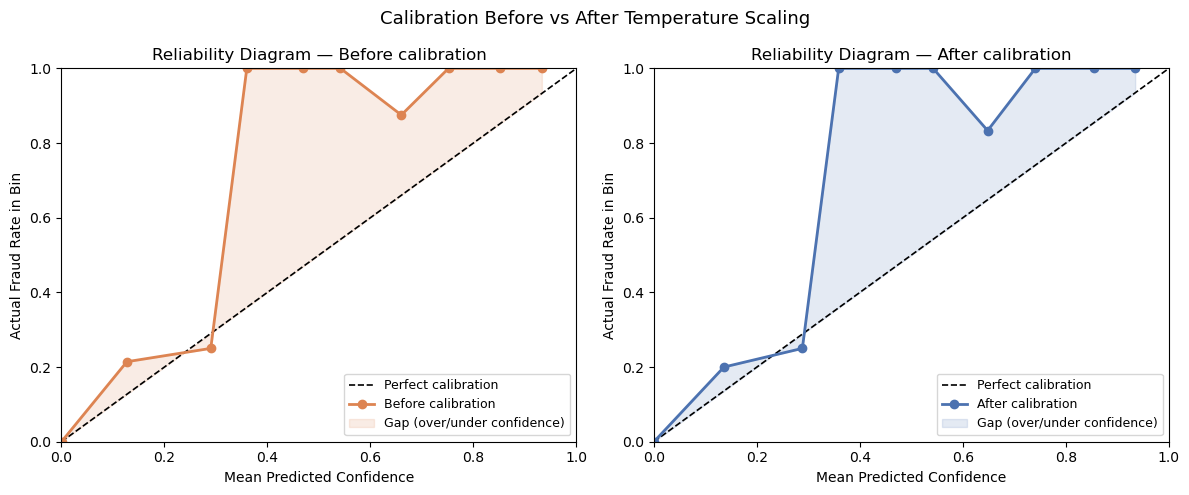

In [7]:
# Reliability diagram — before vs after calibration
# ================================================================
# RELIABILITY DIAGRAM (Calibration Curve)
# ================================================================
def reliability_diagram(y_true, y_proba_before, y_proba_after, n_bins=10, title="Reliability Diagram"):
    bins = np.linspace(0, 1, n_bins + 1)
    
    def bin_data(yp):
        confs, accs, sizes = [], [], []
        for i in range(n_bins):
            lo, hi = bins[i], bins[i+1]
            mask = (yp >= lo) & (yp < hi)
            if mask.sum() == 0: continue
            confs.append(yp[mask].mean())
            accs.append((y_true[mask] == 1).mean())
            sizes.append(mask.sum())
        return confs, accs, sizes
    
    c1, a1, sz1 = bin_data(y_proba_before)
    c2, a2, sz2 = bin_data(y_proba_after)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for ax, confs, accs, lbl, col in [
        (axes[0], c1, a1, "Before calibration", "#DD8452"),
        (axes[1], c2, a2, "After calibration",  "#4C72B0")
    ]:
        ax.plot([0,1], [0,1], 'k--', linewidth=1.2, label="Perfect calibration")
        ax.plot(confs, accs, 'o-', color=col, linewidth=2, markersize=6, label=lbl)
        ax.fill_between(confs, confs, accs, alpha=0.15, color=col, label="Gap (over/under confidence)")
        ax.set_xlabel("Mean Predicted Confidence")
        ax.set_ylabel("Actual Fraud Rate in Bin")
        ax.set_title(f"Reliability Diagram — {lbl}")
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig("outputs/04_calibration_curve.png", dpi=120, bbox_inches='tight')
    plt.show()

reliability_diagram(y_test, y_proba, proba_calibrated,
                    title="Calibration Before vs After Temperature Scaling")


In [6]:
# Save calibration results
# Save confidence monitoring summary
conf_summary = {
    "ece_before_calibration": round(ece_before, 4),
    "ece_after_calibration":  round(ece_after, 4),
    "optimal_temperature":    round(float(optimal_T), 4),
    "ece_improvement_pct":    round(((ece_before - ece_after)/ece_before)*100, 2),
    "confidence_gap_baseline": round(float(np.mean(np.max(model.predict_proba(X_test_scaled), axis=1)) - accuracy_score(y_test, y_pred)), 4),
    "confidence_gap_drifted":  round(float(confidence_gap_drift), 4),
    "ece_drifted":             round(float(ece_drift), 4)
}
import json
with open("outputs/confidence_summary.json", "w") as f:
    json.dump(conf_summary, f, indent=4)

import joblib
joblib.dump(optimal_T, "models/optimal_temperature.pkl")
print("Confidence monitoring summary saved.")
print(json.dumps(conf_summary, indent=2))


Confidence monitoring summary saved.
{
  "ece_before_calibration": 0.0003,
  "ece_after_calibration": 0.0003,
  "optimal_temperature": 0.9906,
  "ece_improvement_pct": 11.7,
  "confidence_gap_baseline": -0.0001,
  "confidence_gap_drifted": -0.019,
  "ece_drifted": 0.0194
}
